MOHAMMED MUBARAK

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", x_test.shape)
print("Testing labels:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


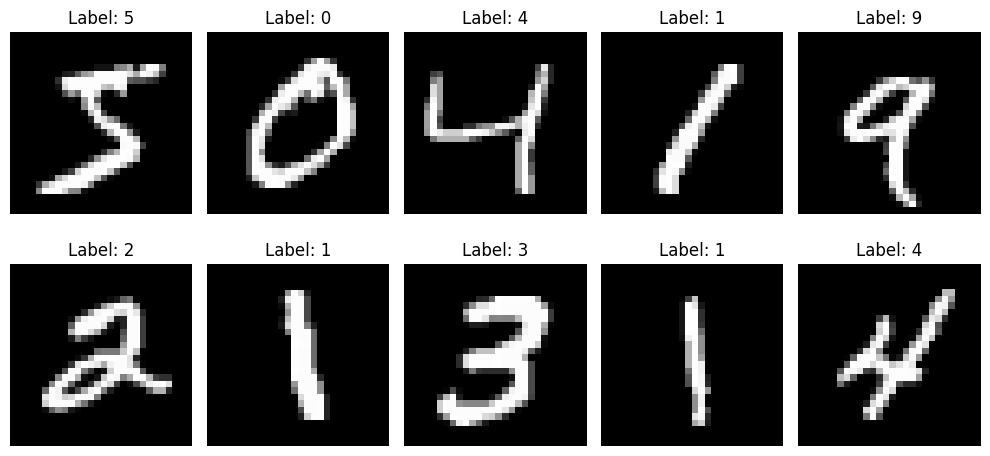

In [ ]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Preprocessing completed")

Preprocessing completed


In [ ]:
model = models.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9184 - loss: 0.2879 - val_accuracy: 0.9548 - val_loss: 0.1579
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9634 - loss: 0.1248 - val_accuracy: 0.9665 - val_loss: 0.1154
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9743 - loss: 0.0855 - val_accuracy: 0.9676 - val_loss: 0.1067
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9806 - loss: 0.0633 - val_accuracy: 0.9720 - val_loss: 0.0960
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9851 - loss: 0.0484 - val_accuracy: 0.9721 - val_loss: 0.0945
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9881 - loss: 0.0381 - val_accuracy: 0.9745 - val_loss: 0.0847
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9910 - loss: 0.0292 - val_accuracy: 0.9733 - val_loss: 0.0917
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9933 - loss: 0.0241 -

In [ ]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Loss: 0.08676881343126297
Test Accuracy: 0.9772999882698059
Test Accuracy: 97.73%


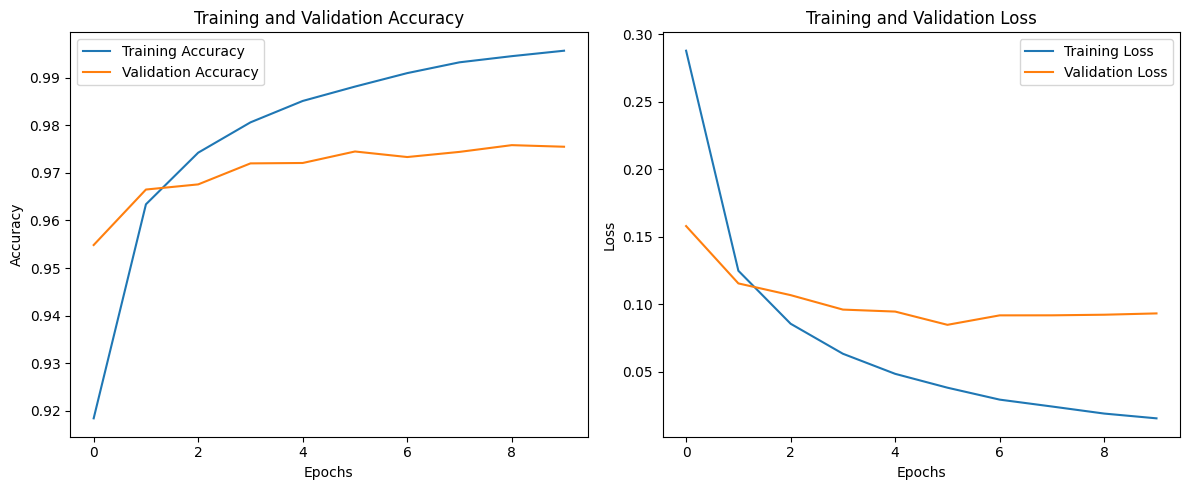

In [ ]:
plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

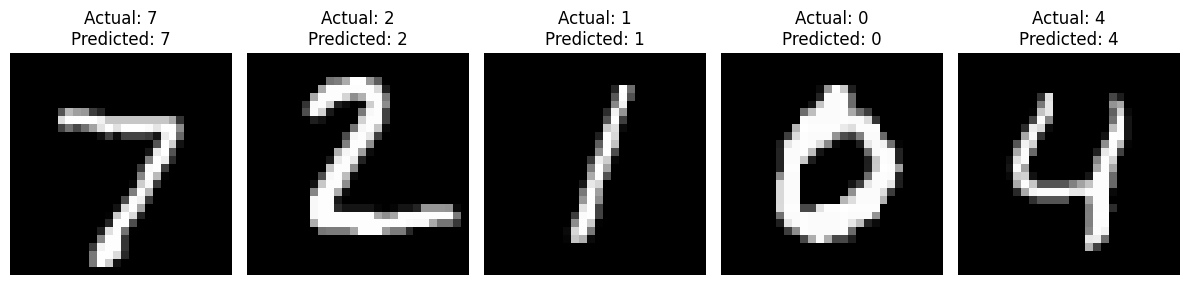

Image 1: Actual = 7, Predicted = 7
Image 2: Actual = 2, Predicted = 2
Image 3: Actual = 1, Predicted = 1
Image 4: Actual = 0, Predicted = 0
Image 5: Actual = 4, Predicted = 4


In [ ]:
# Select 5 test images
sample_images = x_test[:5]
actual_labels = y_test[:5]

# Predict
predictions = model.predict(sample_images, verbose=0)
predicted_labels = np.argmax(predictions, axis=1)

# Display results
plt.figure(figsize=(12, 4))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(sample_images[i], cmap='gray')
    plt.title(
        f"Actual: {actual_labels[i]}\n"
        f"Predicted: {predicted_labels[i]}"
    )
    plt.axis('off')

plt.tight_layout()
plt.show()

# Print comparison
for i in range(5):
    print(
        f"Image {i+1}: "
        f"Actual = {actual_labels[i]}, "
        f"Predicted = {predicted_labels[i]}"
    )

In [ ]:


experiment_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

experiment_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

experiment_history = experiment_model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9263 - loss: 0.2520 - val_accuracy: 0.9578 - val_loss: 0.1430
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9697 - loss: 0.1031 - val_accuracy: 0.9658 - val_loss: 0.1131
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9789 - loss: 0.0692 - val_accuracy: 0.9753 - val_loss: 0.0867
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9859 - loss: 0.0479 - val_accuracy: 0.9753 - val_loss: 0.0844
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9893 - loss: 0.0360 - val_accuracy: 0.9746 - val_loss: 0.0886
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9923 - loss: 0.0261 - val_accuracy: 0.9756 - val_loss: 0.0858
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9935 - loss: 0.0215 - val_accuracy: 0.9741 - val_loss: 0.0969
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9948 - loss: 0.0170 -

In [ ]:
experiment_loss, experiment_accuracy = experiment_model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("Experiment Test Accuracy:",
      f"{experiment_accuracy * 100:.2f}%")

Experiment Test Accuracy: 97.72%


In [ ]:
print("Baseline Test Accuracy:",
      f"{test_accuracy * 100:.2f}%")

print("Experiment Test Accuracy:",
      f"{experiment_accuracy * 100:.2f}%")

difference = experiment_accuracy - test_accuracy

print("Accuracy Difference:",
      f"{difference * 100:.2f} percentage points")

Baseline Test Accuracy: 97.73%
Experiment Test Accuracy: 97.72%
Accuracy Difference: -0.01 percentage points


In [ ]:
experiment_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

experiment_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

experiment_history = experiment_model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9273 - loss: 0.2497 - val_accuracy: 0.9618 - val_loss: 0.1279
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9693 - loss: 0.1030 - val_accuracy: 0.9699 - val_loss: 0.1006
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9789 - loss: 0.0673 - val_accuracy: 0.9720 - val_loss: 0.0924
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9852 - loss: 0.0479 - val_accuracy: 0.9737 - val_loss: 0.0849
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9895 - loss: 0.0346 - val_accuracy: 0.9790 - val_loss: 0.0761
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9919 - loss: 0.0268 - val_accuracy: 0.9746 - val_loss: 0.0939
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9935 - loss: 0.0207 - val_accuracy: 0.9766 - val_loss: 0.0866
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9944 - loss: 0.0181 -

In [ ]:
experiment_loss, experiment_accuracy = experiment_model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("Experiment Test Accuracy:",
      f"{experiment_accuracy * 100:.2f}%")

Experiment Test Accuracy: 97.92%


In [ ]:
print("Baseline Test Accuracy:",
      f"{test_accuracy * 100:.2f}%")

print("Experiment Test Accuracy:",
      f"{experiment_accuracy * 100:.2f}%")

difference = experiment_accuracy - test_accuracy

print("Accuracy Difference:",
      f"{difference * 100:.2f} percentage points")

Baseline Test Accuracy: 97.73%
Experiment Test Accuracy: 97.92%
Accuracy Difference: 0.19 percentage points
